## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np
import pandas as pd

project_path = 'G:\\Mi unidad\\Tesis v1\\Movement_clasify' 
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)



#Rutas donde tenemos demás recursos
scripts_path = os.path.join(project_path, 'scripts')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1\Movement_clasify
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts


### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

En el caso de este dataset, la distribución de clases quedaría de la siguiente manera: 
    "rest" -> 0

    "right_i" -> 1

    "left_i"->2

    "hands_i" -> 3

    "feet_i" -> 4

    "right_m" -> 5

    "left_m" -> 6

    "hands_m" -> 7
    
    "feet_m" -> 8

In [2]:
"""            
            0: FULL           
            1: SOLO MOTOR (5 clases)
            2: SOLO IMAGINADO 5 CLASES
            3: 9 CLASES SIN FUSIÓN
            4: REST-IZQ-DER fusionado
            5: REST-MANOS-PIES fusionado
            6: REST-IZQ-DER SOLO MOTOR
            7: REST-MANOS-PIES SOLO MOTOR
            8: TODAS CLASES BINARIO (REST vs MOVIMIENTO)
            9: REST vs MOVIMIENTO SOLO MOTOR
            10: MANOS VS PIES, fusionado
            11: MANOS VS PIES, solo motor
            12: DERECHA vs IZQUIERDA, fusionado 
            13: DERECHA vs IZQUIERDA, solo motor
            14: IZQ-DER-MANO-PIES FUSIONADAS
            15: IZQ-DER-MANO-PIES SOLO MOTOR
"""

#Probamos nuestro nuevo objeto
pick = 7
obj = dl.Selection(pick=pick, Debug=True)



### 3) Una vez creado el objeto, se puede establecer una ruta al dataset para ejecutar y a su vez se pueden elegir los canales que se quieren usar para el entrenamiento con el atributo "pick_ch"
(Recordatorio: debo crear una función de fet channels, pues ya existe el resume_dataset pero para evitar tantos datos)

In [3]:
path_dataset = "Recursos/new/7_ch/101_subs/eeg_dataset_0.00015rate.npz"
obj.load(path_dataset)
#obj.pick_ch(["C3..", "C4..", "Cz.."])



✔️ Dataset cargado desde: Recursos/new/7_ch/101_subs/eeg_dataset_0.00015rate.npz
✔ Aplicando filtro de modos: ['HF_M']
Modos presentes antes del filtro: ['HF_I' 'HF_M' 'LR_I' 'LR_M']
Modos presentes después del filtro: ['HF_M']
✔ Pick aplicado en load()
Clases: [0 7 8]
Modes: ['HF_M']
Runs: [ 5  9 13]
X: (42615, 7, 160)
Canales disponibles: ['C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..']


### 4) Una vez todos los argumentos listos, se puede usar el atributo "pipeline" para ejecutar todo lo pedido

In [4]:
obj.pipeline()

# Debug inmediato
print("y único:", np.unique(obj.y))
print("conteos:", np.unique(obj.y, return_counts=True))
print("X shape:", obj.X.shape)



✔ Sin fusión. Solo remapeo.
Clases finales: ['rest', 'hands_m', 'feet_m']
{np.int32(0): np.int64(21105), np.int32(1): np.int64(10620), np.int32(2): np.int64(10890)}
y único: [0 1 2]
conteos: (array([0, 1, 2], dtype=int32), array([21105, 10620, 10890]))
X shape: (42615, 7, 160)


### 4.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [5]:
obj.resume_data()



X shape: (42615, 7, 160)
y shape: (42615,)
sub shape: (42615,)
trial shape: (42615,)
run shape: (42615,)
Número de clases: 3
Número de sujetos: 100

Clases:
   codigo   nombre
0       0     rest
1       1  hands_m
2       2   feet_m

Conteo por clase:
0    21105
1    10620
2    10890
Name: count, dtype: int64


### 5) Con el método "pick_fine" se pueden separtar los datos en aquellos datos de entrenamiento y aquellos datos de ajuste fino 
(Recordatorio: debo hacer un atributo de get_model para aquellos que no quieran dividir el dataset)

In [5]:
data_model, data_fine, data_test = obj.pick_fine(7, run_split=True)

print("Distribución de clases en data_model:", np.unique(data_model.y, return_counts=True))
print("Distribución de clases en data_fine:", np.unique(data_fine.y, return_counts=True))
print("Distribución de clases en data_test:", np.unique(data_test.y, return_counts=True))

print("data_test:", data_test.X.shape, data_test.y.shape)


channels = len(data_model.X[0])




✔ Sujetos entrenamiento general: [  1   2   3   4   5   6   8   9  10  11  12  14  15  16  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 105 106 107 108]
✔ Sujeto fine-tune: 7
✔ Run reservada para test: 5
Runs fine-tune: [ 9 13]
Runs test: [5]
Shape modelo: (42165, 7, 160)
Shape fine: (300, 7, 160)
Shape test: (150, 7, 160)
Distribución de clases en data_model: (array([0, 1, 2], dtype=int32), array([20880, 10510, 10775]))
Distribución de clases en data_fine: (array([0, 1, 2], dtype=int32), array([150,  75,  75]))
Distribución de clases en data_test: (array([0, 1, 2], dtype=int32), array([75, 35, 40]))
data_test: (150, 7, 160) (150,)


### 6) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

Iniciando pipeline de entrenamiento EEGNet...
Split de test: False
Modo de split: subject
n_groups: 99
n_temp: 10
Split por grupo:
  Train: 37865 muestras, grupos: [  2   3   4   5   6   8   9  10  11  14  15  16  18  19  20  21  23  24
  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  42  43
  44  46  48  49  50  51  52  53  54  55  56  57  58  59  60  64  65  66
  67  68  69  71  73  74  75  76  77  78  79  80  81  82  84  85  86  87
  88  89  90  91  92  94  95  96  97  98  99 100 101 102 103 106 108]
  Val:   4300 muestras, grupos: [  1  12  22  45  47  70  72  93 105 107]
  Test:  0 muestras, grupos: []
Modo split: subject
X_train: (37865, 7, 160)
X_val: (4300, 7, 160)
X_test: (0, 7, 160)
Antes de ajustar: (37865, 7, 160) Después de ajustar para Keras: (37865, 7, 160, 1)
distribución de clases después de undersample rest: {np.int32(0): np.int64(18720), np.int32(1): np.int64(9430), np.int32(2): np.int64(9715)}
Epoch 1/60


c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1184/1184 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4207 - loss: 1.0562 - val_accuracy: 0.4140 - val_loss: 1.0394
Epoch 2/60
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4519 - loss: 1.0191 - val_accuracy: 0.4300 - val_loss: 1.0146
Epoch 3/60
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4603 - loss: 1.0099 - val_accuracy: 0.4914 - val_loss: 1.0016
Epoch 4/60
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4641 - loss: 1.0045 - val_accuracy: 0.4795 - val_loss: 0.9958
Epoch 5/60
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4734 - loss: 1.0015 - val_accuracy: 0.4937 - val_loss: 0.9972
Epoch 6/60
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4745 - loss: 0.9960 - val_accuracy: 0.4849 - val_loss: 0.9949
Epoch 7/60
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4775 - loss: 0.9931 - val_accuracy: 0.4798 - val_loss: 0.9994
Epoch 8/60
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4769 - loss: 0.9941 - val_accu

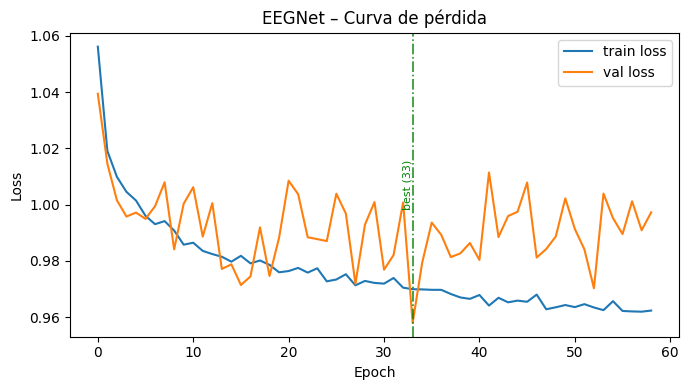

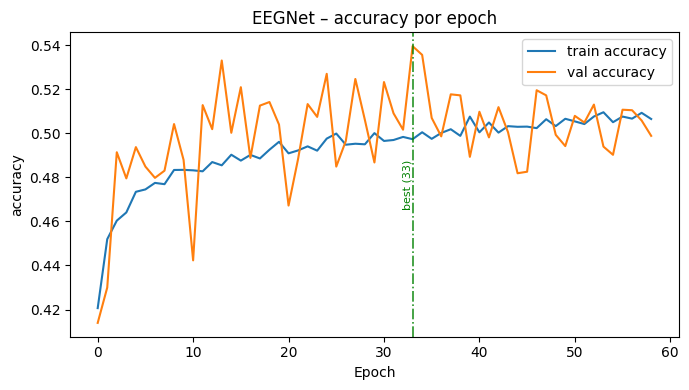


 EVALUACIÓN EEGNet

[Métricas globales]
Accuracy                  : 0.4000
Balanced accuracy         : 0.5321
Macro precision           : 0.2702
Macro recall              : 0.5321
Macro F1                  : 0.3574
Weighted F1               : 0.2674
Cohen's kappa             : 0.1969
Matthews corrcoef         : 0.2673
Log loss                  : 1.2984
ROC-AUC macro             : 0.7306
Chance level              : 0.3333
Accuracy over chance norm : 0.1000

[Clases]
  0: rest
  1: hands_m
  2: feet_m

[Reporte de clasificación]
              precision    recall  f1-score   support

        rest       0.00      0.00      0.00        75
     hands_m       0.44      0.77      0.56        35
      feet_m       0.38      0.82      0.52        40

    accuracy                           0.40       150
   macro avg       0.27      0.53      0.36       150
weighted avg       0.20      0.40      0.27       150


[Interpretación rápida]
- Accuracy: rendimiento global.
- Balanced accuracy: accurac

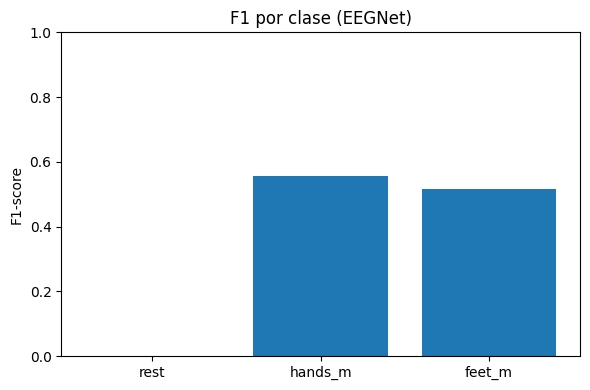

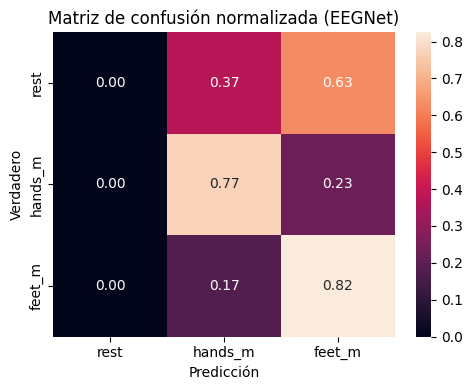

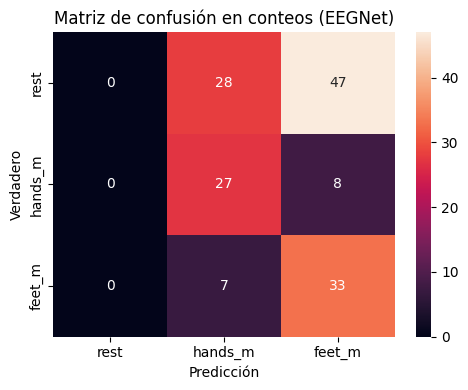

{'title': 'EEGNet',
 'y_true': array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2]),
 'y_pred': array([2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2,
        2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1,
        1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1,
        1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1,
        2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
        

In [6]:


modelo, history, mean, std, keras_split, info = dl.eeg_train(
    data_model, test_size=0.15, val_size=0.1, undersample_rest=False, use_class_weight=True,
    mode="subject", make_test=False, test_run=data_test, dynamic_lr = False,
    epochs=60, patience_level='medium',
    Lr=5e-4,  dropout_rate=0.25, batch = 32,
    debug=True
)

dl.plot_history(history, lr_schedule=info["Lr_grid"], best_epoch = info["best_epoch"])
dl.evaluate(modelo, keras_split, obj.label_map)

##### Examinar modelo obtenido

In [12]:
import itertools
import pandas as pd
import numpy as np

# ── Hiperparámetros a explorar ──────────────────────────────────────────────
grid = {
    "Lr":               [5e-4, 1e-3],
    "F1":               [8, 16],
    "dropout_rate":     [0.25, 0.5]
    
}

# ── Fijos ────────────────────────────────────────────────────────────────────
FIXED = dict(
    mode            = "subject",
    epochs          = 100,
    patience_level  = "high",
    early_monitor   = "val_loss",
    val_size        = 0.10,
    make_test       = False,
    test_run        = data_test,   # run reservado, nunca toca train/val
    dynamic_lr      = True,
    Lr_grid         = None,        # schedule por defecto dentro de eeg_train
    batch           = 32,
    kern_length     = None,        # auto → sfreq//2 = 80
    debug           = False,
)

# ── Grid search ──────────────────────────────────────────────────────────────
keys   = ["Lr", "F1", "dropout_rate", "balance"]
combos = list(itertools.product(grid["Lr"], grid["F1"], grid["dropout_rate"]))

rows        = []
best_score  = -np.inf
best_bundle = None
exp_id      = 0

for Lr, F1, dropout_rate in combos:

    exp_id += 1
    label = (f"exp{exp_id:02d} | Lr={Lr} F1={F1} drop={dropout_rate} ")
    print(f"[{exp_id}/{len(combos)}] {label}")

    try:
        modelo, history, mean, std, keras_split, info = dl.eeg_train(
            data_model,
            Lr               = Lr,
            F1               = F1,
            dropout_rate     = dropout_rate,
            undersample_rest = True,
            use_class_weight = True,
            mode             = "subject",
            epochs           = 60,
            patience_level   = "high",
            early_monitor    = "val_loss",
            val_size         = 0.10,
            make_test        = False,
            test_run         = data_test,
            dynamic_lr       = True,
            Lr_grid          = None,
            batch            = 32,
            kern_length      = None,
            debug            = False,
)

        metrics = dl.evaluate(
            modelo,
            test_run        = dl.normalize_run(data_test, mean, std),
            label_map       = obj.label_map,
            plot            = False,
            verbose         = False,
        )

        score = metrics["balanced_accuracy"]

        row = {
            "exp_id":           exp_id,
            "lr":               Lr,
            "F1":               F1,
            "dropout_rate":     dropout_rate,
            "accuracy":         metrics["accuracy"],
            "balanced_accuracy":score,
            "macro_f1":         metrics["macro_f1"],
            "cohen_kappa":      metrics["cohen_kappa"],
            "f1_rest":          metrics["f1_rest"],
            "f1_right_m":       metrics["f1_right_m"],
            "f1_left_m":        metrics["f1_left_m"],
            "epochs_run":       len(history.history["val_loss"]),
        }
        rows.append(row)

        if score > best_score:
            best_score  = score
            best_bundle = {
                "model":        modelo,
                "mean":         mean,
                "std":          std,
                "keras_split":  keras_split,
                "info":         info,
                "metrics":      metrics,
                "config": dict(Lr=Lr, F1=F1, dropout_rate=dropout_rate),
            }
            print(f"  ★ Nuevo mejor: balanced_acc={score:.4f}")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        rows.append({"exp_id": exp_id, "lr": Lr, "F1": F1,
                     "dropout_rate": dropout_rate, "error": str(e)})

# ── Resultados ────────────────────────────────────────────────────────────────
df_grid_general = pd.DataFrame(rows).sort_values("balanced_accuracy", ascending=False)
display(df_grid_general)

print(f"\n★ Mejor configuración (balanced_acc={best_score:.4f}):")
print(best_bundle["config"])

[1/8] exp01 | Lr=0.0005 F1=8 drop=0.25 


G:\Mi unidad\Tesis v1\Movement_clasify\scripts\backend_DL_v2.py:987: UserWarning: dynamic_lr=True pero no se proporcionó Lr_grid. Se usará un schedule por defecto.
  warnings.warn("dynamic_lr=True pero no se proporcionó Lr_grid. Se usará un schedule por defecto.")


Undersampling: clase 0 recortada de 37925 a 19405 muestras.


c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test loss=1.1040, acc=0.3267
  ✗ Error: 'numpy.ndarray' object has no attribute 'X'
[2/8] exp02 | Lr=0.0005 F1=8 drop=0.5 


...

G:\Mi unidad\Tesis v1\Movement_clasify\scripts\backend_DL_v2.py:987: UserWarning: dynamic_lr=True pero no se proporcionó Lr_grid. Se usará un schedule por defecto.
  warnings.warn("dynamic_lr=True pero no se proporcionó Lr_grid. Se usará un schedule por defecto.")


Undersampling: clase 0 recortada de 37925 a 19405 muestras.


c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test loss=1.1198, acc=0.2867
  ✗ Error: 'numpy.ndarray' object has no attribute 'X'


KeyError: 'balanced_accuracy'

In [10]:
#Guardamos el modelo y sus parámetros de normalización
clases = np.unique(obj.pick)
path = f"Recursos/models/general/v4/{pick}_mode_trained_models_v1"

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(
    model=modelo,
    mean=mean,
    std=std,
    label_map=obj.label_map,
    path=path,

    name=f"EEGNet_{channels}_dynamicLR"
)



Modelo guardado: Recursos/models/general/v4/7_mode_trained_models_v1\EEGNet_7_dynamicLR.keras
Parámetros guardados: Recursos/models/general/v4/7_mode_trained_models_v1\EEGNet_7_dynamicLR.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('hands_m'), 2: np.str_('feet_m')}


Se realizará evaluación en el set reservado
[Fine-tune] Validation loss=0.5899, acc=0.7600


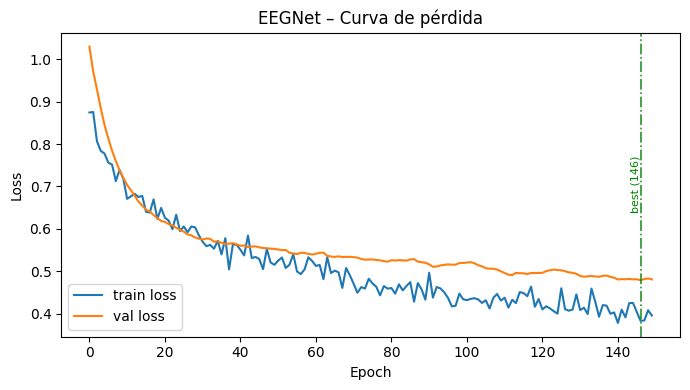

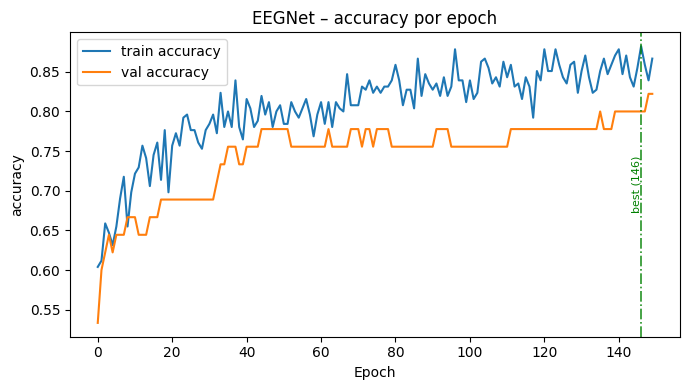

In [11]:

modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft, info_ft = dl.eeg_fine(modelo, data_fine, mean = mean, std = std, test_size=0.15, val_size=0.15,
                                                                    make_test=False, test_run=data_test, dynamic_unfreeze = False,
                                                                    debug=False, epochs=150, lr=2e-4, batch_size=16, unfreeze_last_n=64, normalize=True,
                                                                    dynamic_lr=False,use_class_weight = True, patience_level='high')

dl.plot_history(histor_ft, lr_schedule=info_ft["Lr_grid"], unfreeze_schedule=info_ft["unfreeze_grid"], best_epoch=info_ft["best_epoch"])



 EVALUACIÓN EEGNet

[Métricas globales]
Accuracy                  : 0.7600
Balanced accuracy         : 0.8167
Macro precision           : 0.7962
Macro recall              : 0.8167
Macro F1                  : 0.7682
Weighted F1               : 0.7648
Cohen's kappa             : 0.6451
Matthews corrcoef         : 0.6844
Log loss                  : 0.5899
ROC-AUC macro             : 0.9522
Chance level              : 0.3333
Accuracy over chance norm : 0.6400

[Clases]
  0: rest
  1: hands_m
  2: feet_m

[Reporte de clasificación]
              precision    recall  f1-score   support

        rest       0.98      0.60      0.74        75
     hands_m       0.54      1.00      0.70        35
      feet_m       0.87      0.85      0.86        40

    accuracy                           0.76       150
   macro avg       0.80      0.82      0.77       150
weighted avg       0.85      0.76      0.76       150


[Interpretación rápida]
- Accuracy: rendimiento global.
- Balanced accuracy: accurac

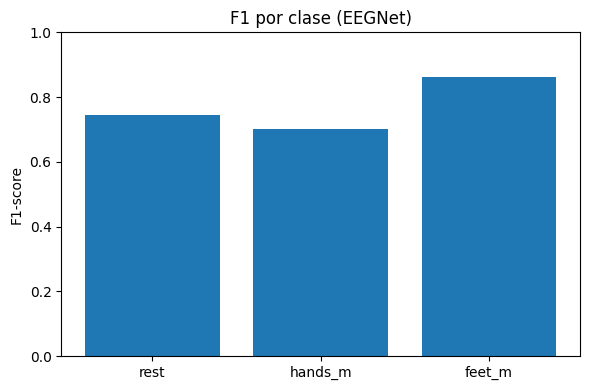

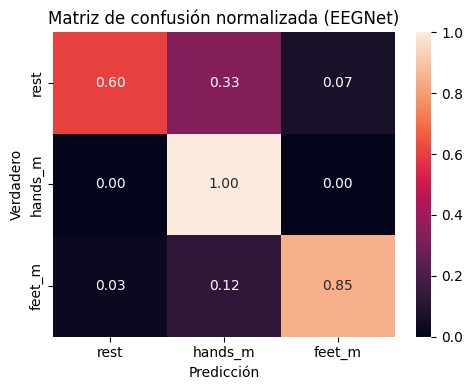

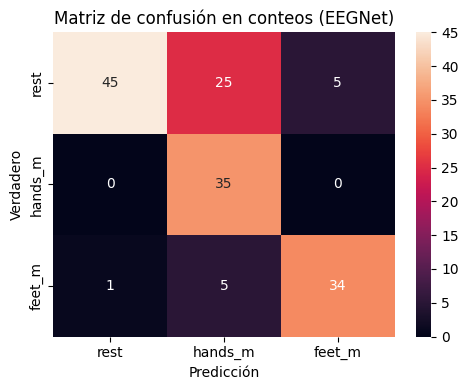

{'title': 'EEGNet',
 'y_true': array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2]),
 'y_pred': array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 2, 1, 2, 0,
        0, 0, 0, 2, 2, 1, 2, 2, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 2, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 2, 1, 2, 2, 1, 0, 0, 0, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 2, 2, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 0, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        

In [12]:
dl.evaluate(modelo_ft, keras_split_ft, obj.label_map)

[Intento 1]: Probando con las métricas Lr = 0.0002, unfreeze = 64, batch = 16 y weight = True
Undersampling: clase 0 recortada de 125 a 70 muestras.
Se realizará evaluación en el set reservado
[Fine-tune] Validation loss=0.6783, acc=0.7133
🔥 Nuevo mejor modelo: exp 1 | macro_f1=0.7146
Accuracy:          0.7133
Balanced accuracy: 0.7622
Macro F1:          0.7146
[Intento 2]: Probando con las métricas Lr = 0.0002, unfreeze = 64, batch = 8 y weight = True
Undersampling: clase 0 recortada de 125 a 70 muestras.
Se realizará evaluación en el set reservado
[Fine-tune] Validation loss=0.6333, acc=0.7667
🔥 Nuevo mejor modelo: exp 2 | macro_f1=0.7717
Accuracy:          0.7667
Balanced accuracy: 0.8250
Macro F1:          0.7717
[Intento 3]: Probando con las métricas Lr = 0.0002, unfreeze = 64, batch = 32 y weight = True
Undersampling: clase 0 recortada de 125 a 70 muestras.
Se realizará evaluación en el set reservado
[Fine-tune] Validation loss=0.6998, acc=0.7067
Accuracy:          0.7067
Balance

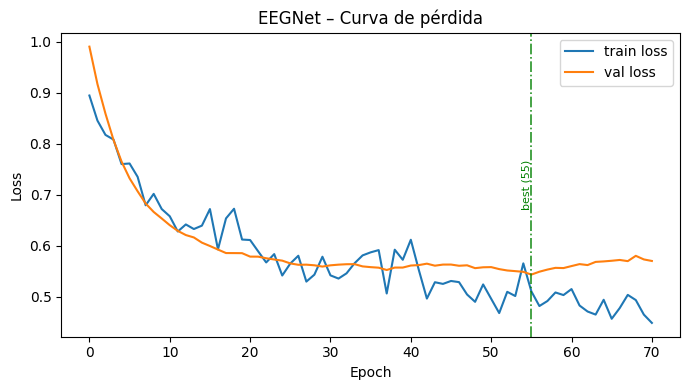

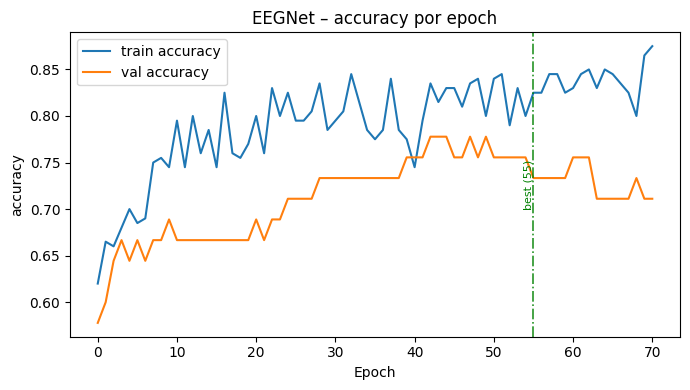

,exp_id,lr,undersample,batch_size,unfreeze_last_n,weight,patience_level,accuracy,balanced_accuracy,macro_f1,weighted_f1,f1_rest,recall_rest,precision_rest,f1_hands_m,recall_hands_m,precision_hands_m,f1_feet_m,recall_feet_m,precision_feet_m
1,2,0.0002,True,8,64,True,high,0.766667,0.825000,0.771674,0.768284,0.750000,0.600000,1.000000,0.721649,1.0,0.564516,0.843373,0.875,0.813953
0,1,0.0002,True,16,64,True,high,0.713333,0.762222,0.714575,0.718704,0.727273,0.586667,0.956522,0.679612,1.0,0.514706,0.736842,0.700,0.777778
2,3,0.0002,True,32,64,True,high,0.706667,0.753889,0.707890,0.713787,0.727273,0.586667,0.956522,0.666667,1.0,0.500000,0.729730,0.675,0.794118


In [ ]:
#Pequeño grid search para mejores parámetros 

rows = []

Lr_list = [2e-4]
batchs = [16, 8, 32]
unfreeze_list = [64, 8]
patience = 'high'
dynamic = False
epoch_list = [150]
weight_list = [True]
under = [False,True]
epoch=150
weight = True


exp_id = 0

best_score = -np.inf
best_bundle = None

for Lr in Lr_list: 
    for under in under: 
        for batch in batchs:
            for unfreeze in unfreeze_list:

                exp_id += 1

                print(f"[Intento {exp_id}]: Probando con las métricas Lr = {Lr}, undersampling = {under}, batch = {batch} y unfreeze = {unfreeze}")

                modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft, info_ft = dl.eeg_fine(modelo, data_fine, mean = mean, std = std, test_size=0.15, val_size=0.15,
                                                                        make_test=False, test_run=data_test, undersample_rest = under, use_class_weight = weight,
                                                                        debug=False, epochs=epoch, lr=Lr, batch_size=batch, unfreeze_last_n=unfreeze, normalize=True,
                                                                        dynamic_lr=dynamic, model_checkpoint=f"checkpoints/ft_exp_{exp_id:03d}.keras")
                
                metrics = dl.evaluate(
                    modelo_ft,
                    keras_split_ft,
                    label_map=obj.label_map,
                    title=f"FT exp {exp_id}",
                    plot=False,
                    verbose=False
                )

            
                row = {
                    "exp_id": exp_id,
                    "lr": Lr,
                    "undersample": under,
                    "batch_size": batch,
                    "unfreeze_last_n": "all" if unfreeze is None else unfreeze,
                    "weight": weight,
                    "patience_level": patience,
                    "accuracy": metrics["accuracy"],
                    "balanced_accuracy": metrics["balanced_accuracy"],
                    "macro_f1": metrics["macro_f1"],
                    "weighted_f1": metrics["weighted_f1"]
                 
                }

                # Métricas por clase
                for name in metrics["class_names"]:
                    clean = str(name).replace(" ", "_")
                    row[f"f1_{clean}"] = metrics.get(f"f1_{clean}")
                    row[f"recall_{clean}"] = metrics.get(f"recall_{clean}")
                    row[f"precision_{clean}"] = metrics.get(f"precision_{clean}")

                    score = metrics["macro_f1"]  # métrica principal para elegir ganador

                if score > best_score:
                    best_score = score

                    best_bundle = {
                        "exp_id": exp_id,
                        "model": modelo_ft,
                        "history": histor_ft,
                        "mean": mean_ft,
                        "std": std_ft,
                        "keras_split": keras_split_ft,
                        "info": info_ft,
                        "metrics": metrics,
                        "params": {
                            "lr": Lr,
                            "batch_size": batch,
                            "unfreeze_last_n": unfreeze,
                            "dynamic": dynamic,
                            "epochs": epoch,
                            "patience_level": patience,
                            "checkpoint_path": f"checkpoints/ft_exp_{exp_id:03d}.keras"
                        }
                         }

                    print(f"🔥 Nuevo mejor modelo: exp {exp_id} | macro_f1={best_score:.4f}")

                rows.append(row)

                print(f"Accuracy:          {metrics['accuracy']:.4f}")
                print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")
                print(f"Macro F1:          {metrics['macro_f1']:.4f}")

df_grid_simple = pd.DataFrame(rows)

df_grid_simple = df_grid_simple.sort_values(
    by=["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False,
    na_position="last"
)

df_grid_simple.to_csv("grid_3_lr_unfreeze_epoch_under.csv", index=False)

df_grid_simple

best_model_ft = best_bundle["model"]
best_history_ft = best_bundle["history"]
best_mean_ft = best_bundle["mean"]
best_std_ft = best_bundle["std"]
best_keras_split_ft = best_bundle["keras_split"]
best_info_ft = best_bundle["info"]
best_metrics_ft = best_bundle["metrics"]
best_params_ft = best_bundle["params"]

print("Mejor experimento:", best_bundle["exp_id"])
print("Mejores parámetros:", best_params_ft)
print("Mejor macro F1:", best_metrics_ft["macro_f1"])

dl.plot_history(best_history_ft, lr_schedule=best_info_ft["Lr_grid"], best_epoch = best_info_ft["best_epoch"] )
df_grid_simple

        


 EVALUACIÓN EEGNet

[Métricas globales]
Accuracy                  : 0.7667
Balanced accuracy         : 0.8250
Macro precision           : 0.7928
Macro recall              : 0.8250
Macro F1                  : 0.7717
Weighted F1               : 0.7683
Cohen's kappa             : 0.6554
Matthews corrcoef         : 0.6929
Log loss                  : 0.6333
ROC-AUC macro             : 0.9416
Chance level              : 0.3333
Accuracy over chance norm : 0.6500

[Clases]
  0: rest
  1: hands_m
  2: feet_m

[Reporte de clasificación]
              precision    recall  f1-score   support

        rest       1.00      0.60      0.75        75
     hands_m       0.56      1.00      0.72        35
      feet_m       0.81      0.88      0.84        40

    accuracy                           0.77       150
   macro avg       0.79      0.83      0.77       150
weighted avg       0.85      0.77      0.77       150


[Interpretación rápida]
- Accuracy: rendimiento global.
- Balanced accuracy: accurac

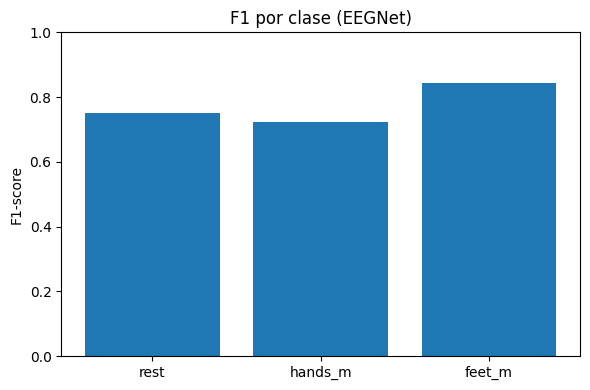

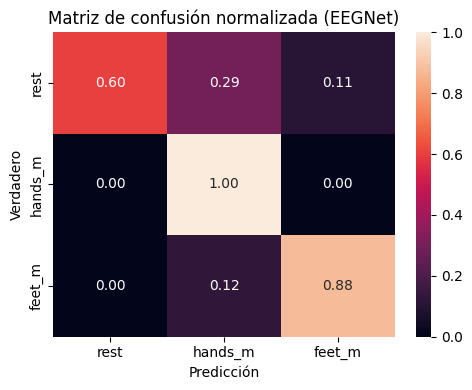

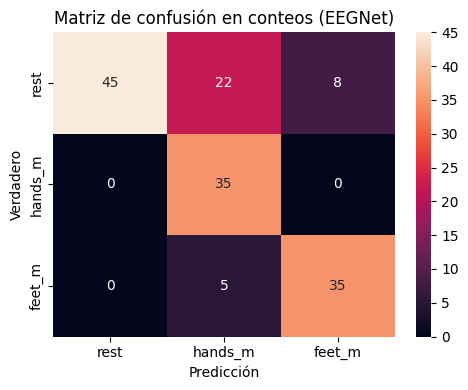

{'title': 'EEGNet',
 'y_true': array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2]),
 'y_pred': array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0,
        0, 0, 0, 2, 2, 1, 2, 2, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 2, 2,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 2, 1, 2, 2, 0, 0, 0, 0, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 1, 0, 0, 2, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 0, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        

In [21]:
dl.evaluate(best_bundle["model"], best_bundle["keras_split"], obj.label_map)

In [13]:

path_f = f"Recursos/models/fined/v4/{pick}_mode_finned_model_dynlr"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(
    model=modelo_ft,
    mean=mean_ft,
    std=std_ft,
    label_map=obj.label_map,
    path=path_f,
    name="EEGNet_subject07_ft"
)


Guardando modelo en: Recursos/models/fined/v4/7_mode_finned_model_dynlr
Modelo guardado: Recursos/models/fined/v4/7_mode_finned_model_dynlr\EEGNet_subject07_ft.keras
Parámetros guardados: Recursos/models/fined/v4/7_mode_finned_model_dynlr\EEGNet_subject07_ft.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('hands_m'), 2: np.str_('feet_m')}


In [22]:
#Cargar modelo genersal y modelo fino
modelo, _ , _ = dl.load_model(model_path = "Recursos/models/general/97_subjects/[0 7 8]_trained_models_v1/Gmodel_31345_97_3ch_7.keras", 
                                  params_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/EEGnet_general_166170_97.npz")

modelo_ft, _ , _ = dl.load_model(model_path = "Recursos/models/fined/v2/6_mode_rid_m_model_v1/EEGNet_LR3_subject07_ft_v1.keras", 
                                  params_path = "Recursos/models/fined/v2/6_mode_rid_m_model_v1/EEGNet_LR3_subject07_ft_v1.npz")

split, _ = dl.split_eeg(data_model.X, data_model.y, data_model.sub, data_model.trial, data_model.run, mode = "subject", test_size=0.15, val_size=0.15)
split_ft, _ = dl.split_eeg(data_fine.X, data_fine.y, data_fine.sub, data_fine.trial, data_fine.run, mode = "trial", test_size=0.15, val_size=0.15)

norm_split, channel_mean, channel_std = dl.normalizar_split(split)
norm_split_ft, _, _ = dl.normalizar_split(split_ft)

keras_split = dl.prepare_keras_split(norm_split)
keras_split_ft = dl.prepare_keras_split(norm_split_ft)


In [16]:
metrics = dl.compare_models(modelo, modelo_ft ,keras_split, keras_split_ft, obj.label_map)


 COMPARACIÓN MODELO GENERAL vs FINE-TUNING 

[ MODELO GENERAL ]
Accuracy : 0.3600
Macro F1 : 0.3235

[ FINE-TUNING ]
Accuracy : 0.8400
Macro F1 : 0.8414

[ MEJORAS ]
Δ Accuracy absoluta : +48.00 puntos
Δ Accuracy relativa : +133.33%
Δ Macro F1 absoluta : +51.79 puntos
Δ Macro F1 relativa : +160.07%


=== Classification Report (General) ===

              precision    recall  f1-score   support

        rest       1.00      0.04      0.08        75
       right       0.65      0.31      0.42        35
        left       0.31      1.00      0.47        40

    accuracy                           0.36       150
   macro avg       0.65      0.45      0.32       150
weighted avg       0.73      0.36      0.26       150


=== Classification Report (Fine-Tuning) ===

              precision    recall  f1-score   support

        rest       0.98      0.72      0.83        75
       right       0.74      0.97      0.84        35
        left       0.78      0.95      0.85        40

    accurac